In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. LOAD DATASET (Menggunakan file yang sudah kita seleksi sebelumnya)
file_path = 'Rev Selected_Features_Boiler_Efficiency Dataset 1.xlsx'
df_raw_1 = pd.read_excel(file_path)

In [3]:
df_raw_1

,Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Main steam temperature (turbine side) (℃),Main steam pressure (turbine side) (MPa),Reheat steam temperature (turbine side) (℃),Feedwater pressure (MPa),Condenser vacuum (kPa),Circulating water outlet temperature (℃),Cold Reheat Temperature (°C),O2 Out APH (%),Coal Flow (t/h),HHV (Kcal/Kg),Temperature HRH,Boiler Eff (%)
0,568.098974,15.970471,566.719831,564.647756,15.853134,566.719831,17.463839,-93.254772,36.582086,322.19,4.57,192.41,4389.444444,566.36,77.915748
1,568.023808,14.907765,563.985723,564.466986,14.799421,563.985723,16.310977,-93.319363,36.544537,320.50,4.36,181.37,4389.444444,565.00,76.294873
2,568.650337,14.869165,565.670929,565.077340,14.769491,565.670929,16.263610,-93.313517,36.551775,320.80,4.41,178.47,4389.444444,565.63,77.886219
3,568.262788,14.422768,564.237198,564.828538,14.321751,564.237198,15.844023,-93.346417,36.504076,321.34,4.66,172.09,4389.444444,564.09,78.367624
4,568.102547,15.204717,565.474856,564.945778,15.099803,565.474856,16.714113,-93.245120,36.704238,320.44,4.40,181.74,4389.444444,565.75,77.856369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,567.188810,15.563528,564.490362,563.225716,15.420673,564.490362,17.206738,-92.739841,37.889208,320.61,3.52,172.99,4237.333333,565.60,89.855113
545,567.664945,14.386963,565.543734,563.826204,14.257886,565.543734,15.898503,-92.818141,37.821999,322.63,3.99,164.77,4237.333333,565.79,88.052730
546,567.590635,14.158093,566.011767,563.660633,14.028464,566.011767,15.580047,-93.038286,37.215704,323.38,4.06,169.38,4237.333333,565.84,85.018900
547,567.520828,14.621877,566.072634,563.597101,14.490684,566.072634,16.085904,-92.750339,37.905170,323.13,3.58,179.69,4237.333333,566.30,83.295960


In [4]:
# Pisahkan fitur dari target (Analisis VIF hanya dilakukan pada fitur input)
target_cols = ['Boiler Eff (%)']
X_raw = df_raw_1.drop(columns=target_cols)

In [5]:
X_raw

,Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Main steam temperature (turbine side) (℃),Main steam pressure (turbine side) (MPa),Reheat steam temperature (turbine side) (℃),Feedwater pressure (MPa),Condenser vacuum (kPa),Circulating water outlet temperature (℃),Cold Reheat Temperature (°C),O2 Out APH (%),Coal Flow (t/h),HHV (Kcal/Kg),Temperature HRH
0,568.098974,15.970471,566.719831,564.647756,15.853134,566.719831,17.463839,-93.254772,36.582086,322.19,4.57,192.41,4389.444444,566.36
1,568.023808,14.907765,563.985723,564.466986,14.799421,563.985723,16.310977,-93.319363,36.544537,320.50,4.36,181.37,4389.444444,565.00
2,568.650337,14.869165,565.670929,565.077340,14.769491,565.670929,16.263610,-93.313517,36.551775,320.80,4.41,178.47,4389.444444,565.63
3,568.262788,14.422768,564.237198,564.828538,14.321751,564.237198,15.844023,-93.346417,36.504076,321.34,4.66,172.09,4389.444444,564.09
4,568.102547,15.204717,565.474856,564.945778,15.099803,565.474856,16.714113,-93.245120,36.704238,320.44,4.40,181.74,4389.444444,565.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,567.188810,15.563528,564.490362,563.225716,15.420673,564.490362,17.206738,-92.739841,37.889208,320.61,3.52,172.99,4237.333333,565.60
545,567.664945,14.386963,565.543734,563.826204,14.257886,565.543734,15.898503,-92.818141,37.821999,322.63,3.99,164.77,4237.333333,565.79
546,567.590635,14.158093,566.011767,563.660633,14.028464,566.011767,15.580047,-93.038286,37.215704,323.38,4.06,169.38,4237.333333,565.84
547,567.520828,14.621877,566.072634,563.597101,14.490684,566.072634,16.085904,-92.750339,37.905170,323.13,3.58,179.69,4237.333333,566.30


In [6]:
# # 2. Preprocessing Dasar
# # Menghilangkan kolom dengan variansi nol (konstanta) yang bisa merusak VIF
# X_raw = X_raw.loc[:, X_raw.var() > 0]
# X_raw = X_raw.fillna(X_raw.median())

In [7]:
# 2. Normalisasi (Z-Score Scaling)
# Ini wajib karena VIF didasarkan pada regresi; perbedaan skala (misal Pressure vs Flow) 
# akan mengacaukan perhitungan jika tidak dinormalisasi.
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled_values, columns=X_raw.columns)

In [8]:
# 3. Perhitungan VIF untuk SEMUA fitur
def calculate_all_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data_frame.columns
    
    vif_list = []
    for i in range(len(data_frame.columns)):
        try:
            vif = variance_inflation_factor(data_frame.values, i)
            vif_list.append(vif)
        except Exception as e:
            # Jika ada varians nol, VIF akan menghasilkan nilai tak terhingga (inf)
            vif_list.append(np.inf)
            
    vif_data["VIF"] = vif_list
    return vif_data.sort_values(by="VIF", ascending=False)

In [9]:
# 1. Atur Pandas agar menampilkan 2 angka di belakang koma (tanpa eksponen)
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

In [10]:
# Eksekusi perhitungan
vif_results = calculate_all_vif(X_scaled)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [11]:
vif_results

,Feature,VIF
2,Reheat steam temperature (boiler side) (℃),inf
5,Reheat steam temperature (turbine side) (℃),inf
1,Main steam pressure (boiler side) (Mpa),22354.17
4,Main steam pressure (turbine side) (MPa),18102.67
6,Feedwater pressure (MPa),504.76
3,Main steam temperature (turbine side) (℃),9.72
0,Main steam temperature (boiler side) (℃),7.88
11,Coal Flow (t/h),6.60
9,Cold Reheat Temperature (°C),4.35
13,Temperature HRH,2.94


Nilai VIF <10 untuk semua fitur terpilih menggunakan feature engineering MrMiMaxG-CVM

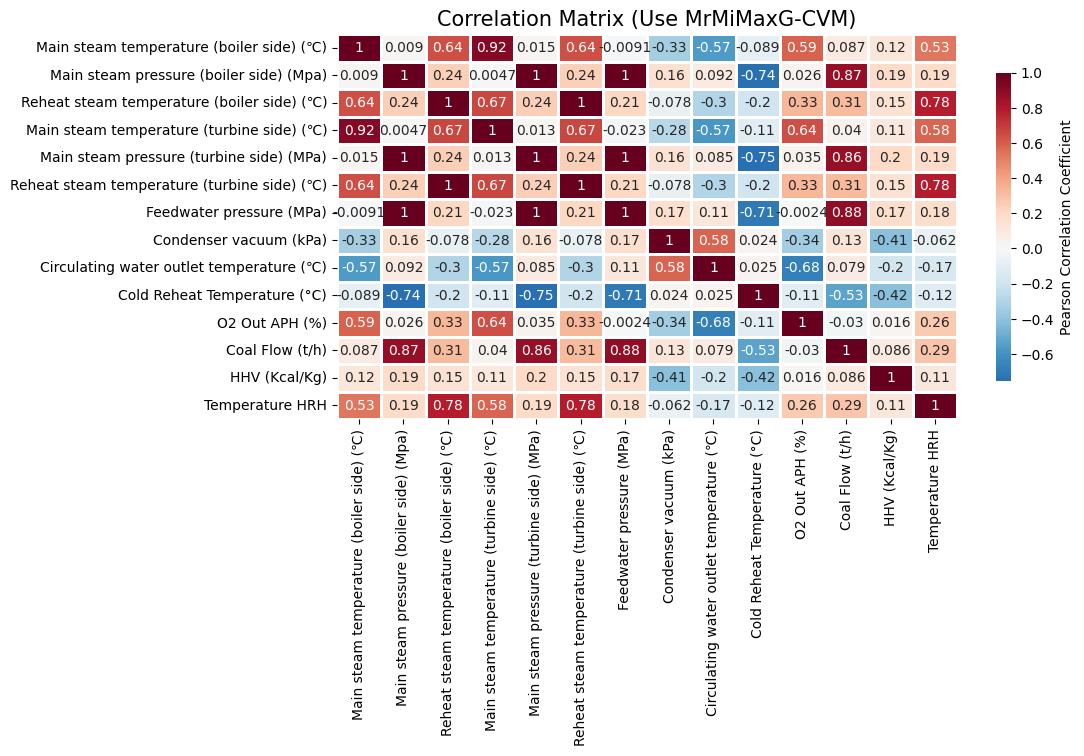

In [12]:
# A. Heatmap Korelasi (Matriks Kompleks)
plt.figure(figsize=(10, 5))
mask = np.tril(np.ones_like(X_scaled.corr(), dtype=bool))
sns.heatmap(X_scaled.corr(), 
            mask=None,          # Menampilkan format rectangle penuh
            annot=True,        # False karena 33 fitur terlalu padat untuk angka
            cmap='RdBu_r',      # Red-Blue (Merah = Positif, Biru = Negatif)
            center=0,           # Putih adalah korelasi 0
            linewidths=1,     # Memberikan garis tipis antar kotak (rectangle)
            linecolor='white',
            square=False,       # Memaksa format mengikuti aspek rasio figsize
            cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient"})
plt.title('Correlation Matrix (Use MrMiMaxG-CVM)', fontsize=15)
plt.show()

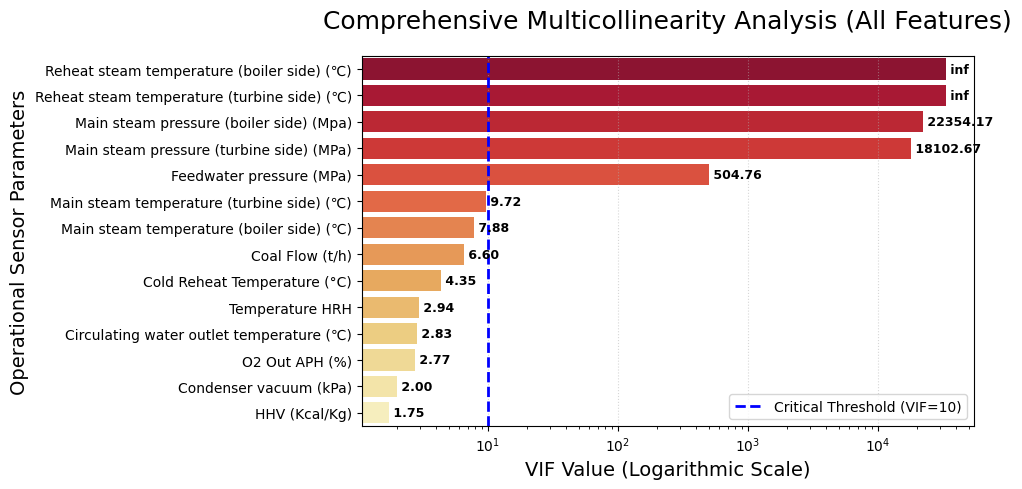

In [13]:
# 2. Mengatasi nilai 'inf' agar bisa tampil di grafik
max_real_vif = vif_results[vif_results['VIF'] != np.inf]['VIF'].max()
vif_results['VIF_Display'] = vif_results['VIF'].replace(np.inf, max_real_vif * 1.5)

# 3. Setup Figure
plt.figure(figsize=(10, 5))

# 4. Plot Bar Chart (PERBAIKAN DI SINI)
# Assign y ke hue dan tambahkan legend=False untuk menghilangkan warning
ax = sns.barplot(
    x='VIF_Display', 
    y='Feature', 
    data=vif_results, 
    palette='YlOrRd_r', 
    hue='Feature',    # Tambahkan ini
    legend=False      # Tambahkan ini
)

# 5. MENGGUNAKAN SKALA LOGARITMIK
plt.xscale('log')

# 6. Menambahkan Garis Threshold VIF=10
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='Critical Threshold (VIF=10)')

# 7. Menambahkan Label Angka di ujung bar
# Menggunakan zip untuk memastikan sinkronisasi data dengan bar
for i, (p, feature_name) in enumerate(zip(ax.patches, vif_results['Feature'])):
    width = p.get_width()
    # Mengambil nilai asli dari dataframe berdasarkan urutan index saat ini
    original_vif = vif_results.iloc[i]['VIF']
    label_text = 'inf' if original_vif == np.inf else f"{original_vif:.2f}"
    
    ax.text(width, p.get_y() + p.get_height()/2, f' {label_text}', 
            va='center', fontsize=9, fontweight='bold')

# 8. Judul dan Label
plt.title('Comprehensive Multicollinearity Analysis (All Features)', fontsize=18, pad=20)
plt.xlabel('VIF Value (Logarithmic Scale)', fontsize=14)
plt.ylabel('Operational Sensor Parameters', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

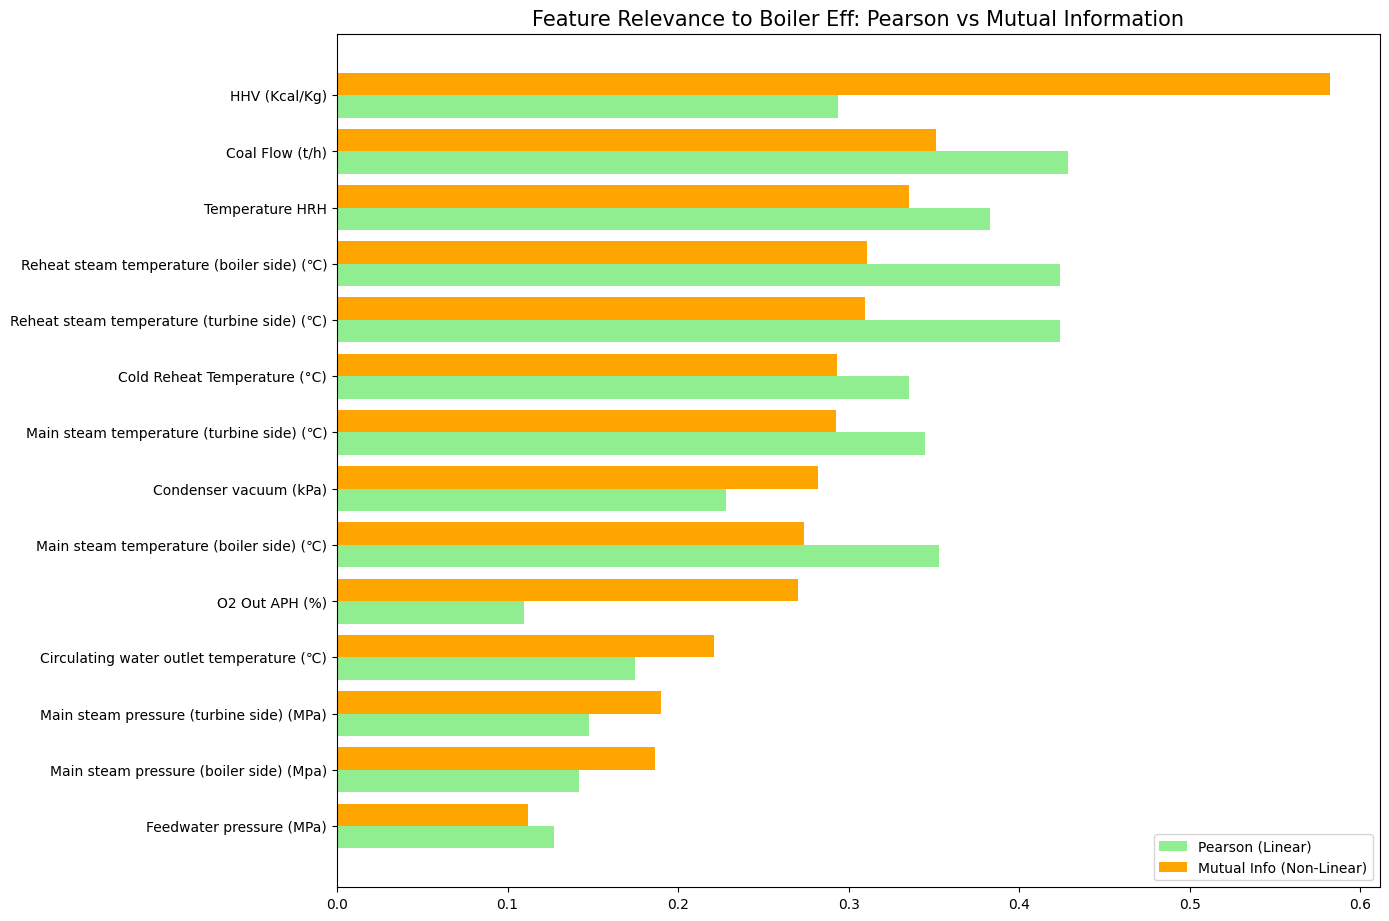

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 1. Load Data
# df_raw_1 sudah didefinisikan sebelumnya
target_cols = ['Boiler Eff (%)']
X = df_raw_1.drop(columns=target_cols)
y_eff = df_raw_1['Boiler Eff (%)']

# 2. Hitung Korelasi Pearson (Linear) terhadap Target
pearson_eff = X.corrwith(y_eff).abs()

# 3. Hitung Mutual Information (Non-Linear) terhadap Target
# Kita perlu mengisi NaN jika ada agar MI bisa berjalan
X_fill = X.fillna(X.median())
mi_eff = mutual_info_regression(X_fill, y_eff, random_state=42)

# 4. Gabungkan dalam DataFrame untuk Visualisasi
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Pearson_Eff': pearson_eff.values,
    'MI_Eff': mi_eff
}).sort_values(by='MI_Eff', ascending=False)

# 5. Visualisasi Perbandingan Pearson vs MI (Justifikasi MrMiMaxG)
plt.figure(figsize=(14, 18))

# Subplot 2: Terhadap Boiler Efficiency
plt.subplot(2, 1, 2)
df_plot_eff = importance_df.sort_values('MI_Eff', ascending=True)
y_pos = np.arange(len(df_plot_eff))
plt.barh(y_pos - 0.2, df_plot_eff['Pearson_Eff'], 0.4, label='Pearson (Linear)', color='lightgreen')
plt.barh(y_pos + 0.2, df_plot_eff['MI_Eff'], 0.4, label='Mutual Info (Non-Linear)', color='orange')
plt.yticks(y_pos, df_plot_eff['Feature'])
plt.title('Feature Relevance to Boiler Eff: Pearson vs Mutual Information', fontsize=15)
plt.legend()

plt.tight_layout()
plt.show()